## **This is the normal parallel workflow**

In [14]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict 

In [42]:
# 1. buildng the state(which is nothing but a class)

class BatsmanState(TypedDict):
    runs: int 
    balls:int
    fours:int
    sixes:int

    sr:float
    bpb:float
    boundary_percent:float 
    summary:str
    

In [48]:
# 3.  Build the function logic or the tools 

# a. calculate_sr 

def calculate_sr(state:BatsmanState):
    sr = (state['runs']/state['balls'])/100
    state['sr'] = sr

    return {'sr':sr} 

# b. calculate_bpb

def calculate_bpb(state:BatsmanState):

    bpb = state['balls']/(state['fours']+state['sixes'])
    state['bpb']= bpb

    return {'bpb':bpb}


# c. calculate_boundary_percent

def calculate_boundary_percent(state:BatsmanState):

    boundary_percent = (((state['fours']*4) +(state['sixes']*6))/state['runs'])*100
    state['boundary_percent']= boundary_percent

    return {'boundary_percent':boundary_percent}


# summary 

def summary(state:BatsmanState):
    summary = f"""
            strike_rate = {state['sr']} 
            Balls_per_boundary = {state['bpb']}
            Boundary_percent = {state['boundary_percent']}
            """
    
    return {'summary':summary}

In [44]:
# 2. Define the graph and add the nodes(functionality to be done or tool)
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr',calculate_sr)
graph.add_node('calculate_bpb',calculate_bpb)
graph.add_node('calculate_boundary_percent',calculate_boundary_percent)
graph.add_node('summary',summary)




In [49]:
# defining the edges 
graph.add_edge(START,'calculate_sr')
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'calculate_boundary_percent')

# summary is defined by all these three 

graph.add_edge('calculate_sr','summary')
graph.add_edge('calculate_bpb','summary')
graph.add_edge('calculate_boundary_percent','summary')

graph.add_edge('summary',END)


Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [50]:
# compile the graph

workflow = graph.compile()

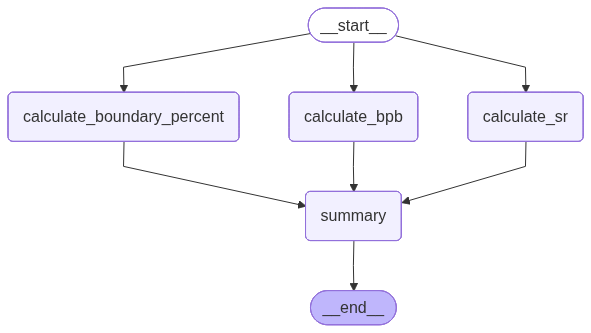

In [36]:
# look at the graph structure 
workflow

In sequential workflow the we can pass the whole state in the output of the node, but in case of the parallel workflow we need  to pass only necessary or partial state. 

In [51]:
# invoking the graph 
initial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

workflow.invoke(initial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 0.02,
 'bpb': 5.0,
 'boundary_percent': 48.0,
 'summary': '\n            strike_rate = 0.02 \n\n            Balls_per_boundary = 5.0 \n\n            Boundary_percent = 48.0\n            '}